# ME 3300 — Prelab 01 Walkthrough: Data Analysis in Python

This **solution notebook** is a reference for you to compare with your own prelab assignment solution.

## 1. Importing packages

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Class-standard text formatting for all figures
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['font.size'] = 10

print("Imports successful!")

Imports successful!


## 2. Loading data — two ways

### Method 1: pandas → DataFrame

In [23]:
# Load with pandas. The path is *relative*: '..' means "up one folder"
# (from Code/ up to Lab_01/, then down into Data/).
df = pd.read_csv('../Data/walkthrough_temperature_data.csv')

df.head(10)  # show the first 10 rows — always inspect data after loading!

,Time (s),Temp (C)
0,0.5,21.368
1,1.0,21.325
2,1.5,21.048
3,2.0,21.205
4,2.5,20.568
5,3.0,21.281
6,3.5,21.298
7,4.0,21.294
8,4.5,22.017
9,5.0,21.757


In [6]:
print("Type: ", type(df))
print("Shape:", df.shape)   # (rows, columns)
print("Columns:", list(df.columns))

Type:  <class 'pandas.DataFrame'>
Shape: (120, 2)
Columns: ['Time (s)', 'Temp (C)']


### Method 2: NumPy → array

In [24]:
# Load the same file with numpy
arr = np.loadtxt('../Data/walkthrough_temperature_data.csv', delimiter=',', skiprows=1)

print("Type: ", type(arr))
print("Shape:", arr.shape)   # (rows, columns)
print("dtype:", arr.dtype)   # every element is the same numeric type
print("First 3 rows:")
print(arr[:3])

Type:  <class 'numpy.ndarray'>
Shape: (120, 2)
dtype: float64
First 3 rows:
[[ 0.5   21.368]
 [ 1.    21.325]
 [ 1.5   21.048]]


### DataFrame vs. array — the key difference

This is one of the most important ideas in this lab:

| | pandas **DataFrame** | NumPy **array** |
|---|---|---|
| Columns | Named (`df['Temp (C)']`) | Numbered (`arr[:, 1]`) |
| Contents | Can mix numbers, text, dates | One numeric type only |
| Best for | Loading/inspecting/organizing data files | Fast math: statistics, fits, element-wise operations |

They work together: a typical workflow is **load with pandas** (robust, keeps labels), then **extract the columns you need as NumPy arrays** for computation using `.values`:

In [ ]:
# Extract each DataFrame column as a plain numpy array
time = df['Time (s)'].values
temp = df['Temp (C)'].values

print(type(df['Temp (C)']))   # a pandas Series (a labeled column)
print(type(temp))             # a numpy array — ready for math

# The numpy load gives the same numbers, just accessed by position:
temp_from_np = arr[:, 1]      # all rows, column index 1
print("pandas and numpy columns match:", np.allclose(temp, temp_from_np))

<class 'pandas.Series'>
<class 'numpy.ndarray'>
pandas and numpy columns match: True


In [ ]:
# Checkpoint 1
NRows1 = df.shape
NRows2 = arr.shape

print(f"Number of rows in pandas DataFrame: {NRows1[0]}")
print(f"Number of rows in numpy array: {NRows2[0]}")

Number of rows in pandas DataFrame: 120
Number of rows in numpy array: 120


> 🟦 **CHECKPOINT 1 (report on Canvas):**
> 1. How many rows of data are in the file (from `df.shape` or `arr.shape`)?
> 2. In the comparison above, which object type keeps column *names*: the DataFrame or the array?

## 3. Indexing and slicing arrays

In [39]:
print(f"Temperature at index 30: {temp[30]} C`")

Temperature at index 30: 21.116 C`


> 🟦 **CHECKPOINT 2 (report on Canvas):**
> 1. What is the value of the **31st** temperature data point?

## 4. Descriptive statistics with NumPy

In [41]:
t_mean   = np.mean(temp)
t_median = np.median(temp)
t_std    = np.std(temp, ddof=1)   # sample standard deviation
t_var    = np.var(temp, ddof=1)   # sample variance

print(f"Mean:               {t_mean:.6f} C")
print(f"Median:             {t_median:.6f} C")
print(f"Sample std (ddof=1): {t_std:.6f} C")
print(f"Sample var (ddof=1): {t_var:.6f} C^2")
print(f"Population std (ddof=0): {np.std(temp, ddof=0):.6f} C   <- slightly smaller")

Mean:               21.248317 C
Median:             21.241000 C
Sample std (ddof=1): 0.348702 C
Sample var (ddof=1): 0.121593 C^2
Population std (ddof=0): 0.347246 C   <- slightly smaller


> 🟦 **CHECKPOINT 3 (report on Canvas):**
> 1. The mean temperature to (6 decimal places).
> 2. The **sample** standard deviation with `ddof=1` (6 decimal places).
> 3. In one sentence: why do we use `ddof=1` for experimental data?

## 5. Building a publication-quality figure

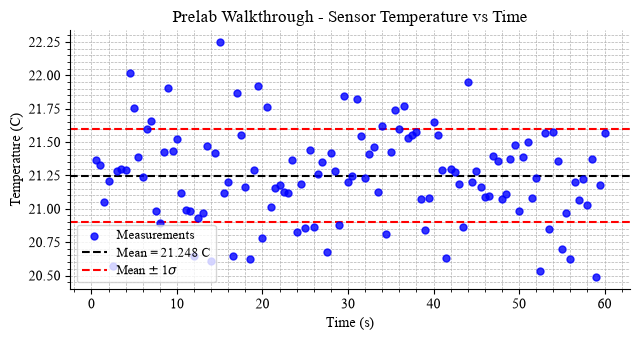

In [42]:
fig1, ax1 = plt.subplots(figsize=(6.5, 3.5))    # size in inches: class standard 6.5 x 3.5
fig1.patch.set_facecolor('white')

# The data: markers only, no connecting lines (it's sampled data!)
ax1.scatter(time, temp, color='blue', s=25, alpha=0.8, zorder=3, label='Measurements')

# Reference lines: mean (black) and mean +/- 1 std (red)
ax1.axhline(t_mean, color='black', linewidth=1.5, linestyle='--',
            label=f'Mean = {t_mean:.3f} C')
ax1.axhline(t_mean + t_std, color='red', linewidth=1.5, linestyle='--',
            label=rf'Mean $\pm$ 1$\sigma$')
ax1.axhline(t_mean - t_std, color='red', linewidth=1.5, linestyle='--')

# Labels, grid, and cleanup — required formatting in this class
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Temperature (C)')
ax1.set_title("Prelab Walkthrough - Sensor Temperature vs Time")
ax1.legend(loc='lower left', fontsize=9)
ax1.grid(True, which='both', linestyle='--', linewidth=0.5)
ax1.minorticks_on()
ax1.spines['top'].set_visible(False)     # remove top border
ax1.spines['right'].set_visible(False)   # remove right border
plt.tight_layout()
plt.show()

### Saving figures

`fig.savefig()` writes the figure to a file. In this class you always save **both** formats at **600 DPI**:

- **.pdf** — vector format, for Canvas submissions
- **.png** — raster format with transparency, for inserting into reports and slides

DPI (dots per inch) sets the resolution of raster output. 600 DPI keeps text crisp when the figure is printed or zoomed; low DPI (72–150) makes smaller files for quick drafts but looks fuzzy in print.

In [43]:
fig1.savefig('../Figures/Prelab01_Walkthrough_Scatter.pdf', dpi=600, bbox_inches='tight')
fig1.savefig('../Figures/Prelab01_Walkthrough_Scatter.png', dpi=600, bbox_inches='tight')
print("Saved! Check your Lab_01/Figures folder.")

Saved! Check your Lab_01/Figures folder.


## 6. Histograms

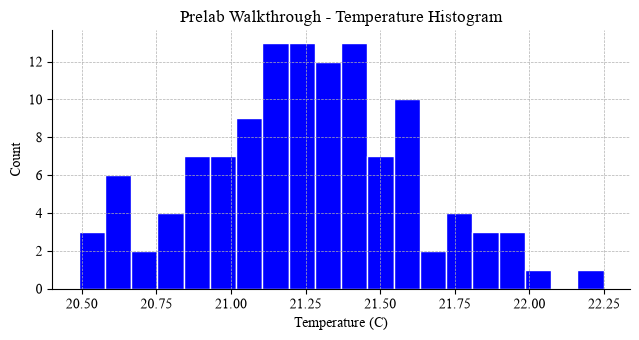

In [45]:
fig2, ax2 = plt.subplots(figsize=(6.5, 3.5))
fig2.patch.set_facecolor('white')

ax2.hist(temp, bins=20, color='blue', edgecolor='white')

ax2.set_xlabel('Temperature (C)')
ax2.set_ylabel('Count')
ax2.set_title("Prelab Walkthrough - Temperature Histogram")
ax2.grid(True, which='both', linestyle='--', linewidth=0.5)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# Try it: re-run this cell with bins=5, then bins=60. What changes?

## 7. Linear curve fits and confidence intervals

In [47]:
# Spring calibration data (typed in directly as numpy arrays)
disp  = np.array([0.0,   5.0,   10.0,   15.0,   20.0,   25.0,   30.0])    # mm
force = np.array([1.683, 4.976, 10.150, 14.364, 16.729, 21.219, 26.177])  # N

coeffs = np.polyfit(disp, force, 1)      # [slope, intercept]
force_fit = np.polyval(coeffs, disp)     # fitted F at each measured x

print(f"Slope (spring constant k): {coeffs[0]:.4f} N/mm")
print(f"Intercept (preload):       {coeffs[1]:.4f} N")

Slope (spring constant k): 0.8039 N/mm
Intercept (preload):       1.5554 N


### How good is the fit? The standard error of the fit

**standard error of the fit**:

$$s_{yx} = \sqrt{\frac{\sum_{i=1}^{N}(y_i - y_{c_i})^2}{\nu}}$$

In [48]:
N  = len(force)
nu = N - 2                       # linear fit estimates 2 parameters -> N - 2
residuals = force - force_fit    # measurement minus fit, point by point
s_yx = np.sqrt(np.sum(residuals**2) / nu)

print(f"N = {N}, degrees of freedom nu = {nu}")
print(f"Standard error of fit s_yx = {s_yx:.4f} N")

N = 7, degrees of freedom nu = 5
Standard error of fit s_yx = 0.7081 N


### The t-value: reading a t-table with `scipy` 

$$q = 1 - \frac{\alpha}{2} = 1 - \frac{0.05}{2} = 0.975$$

In [49]:
t_wrong = stats.t.ppf(0.95, df=nu)    # one-tailed 95% -> only a 90% CI. Common mistake!
t_val   = stats.t.ppf(0.975, df=nu)   # correct for a two-sided 95% CI

print(f"stats.t.ppf(0.95,  df=5) = {t_wrong:.4f}   <- does NOT match the t-table's 95% column")
print(f"stats.t.ppf(0.975, df=5) = {t_val:.4f}   <- matches the table value 2.571")

# The 95% confidence band on the fit:
CI = t_val * s_yx                     # half-width of the confidence interval
print(f"95% CI half-width = {CI:.4f} N")

stats.t.ppf(0.95,  df=5) = 2.0150   <- does NOT match the t-table's 95% column
stats.t.ppf(0.975, df=5) = 2.5706   <- matches the table value 2.571
95% CI half-width = 1.8203 N


### Uncertainty of the slope

$$S_{a_1} = s_{yx}\sqrt{\frac{1}{\sum_{i=1}^{N}(x_i - \bar{x})^2}}$$

In [50]:
S_a1 = s_yx / np.sqrt(np.sum((disp - np.mean(disp))**2))
print(f"Standard error of the slope S_a1 = {S_a1:.5f} N/mm")
print(f"Report the spring constant as: k = {coeffs[0]:.3f} +/- {t_val*S_a1:.3f} N/mm (95%)")

Standard error of the slope S_a1 = 0.02676 N/mm
Report the spring constant as: k = 0.804 +/- 0.069 N/mm (95%)


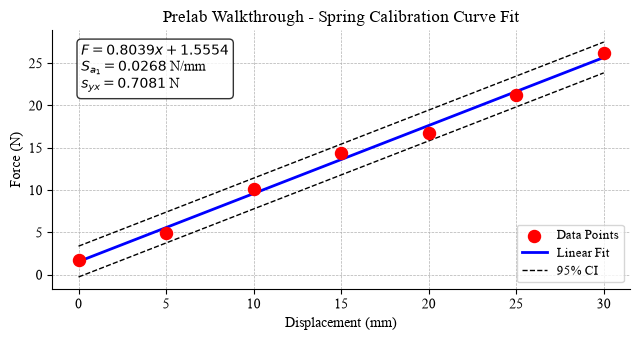

In [51]:
# Put it all together on one figure
x_line = np.linspace(disp.min(), disp.max(), 200)   # dense x values for smooth lines
fit_line = np.polyval(coeffs, x_line)

fig3, ax3 = plt.subplots(figsize=(6.5, 3.5))
fig3.patch.set_facecolor('white')

ax3.scatter(disp, force, color='red', s=75, zorder=5, label='Data Points')
ax3.plot(x_line, fit_line, color='blue', linewidth=2, label='Linear Fit')
ax3.plot(x_line, fit_line + CI, color='black', linewidth=1, linestyle='--', label='95% CI')
ax3.plot(x_line, fit_line - CI, color='black', linewidth=1, linestyle='--')

# Annotate with the fit equation and errors. Units: s_yx has y units (N);
# S_a1 has slope units (N/mm).
fit_label = (f'$F = {coeffs[0]:.4f}x + {coeffs[1]:.4f}$\n'
             f'$S_{{a_1}} = {S_a1:.4f}$ N/mm\n'
             f'$s_{{yx}} = {s_yx:.4f}$ N')
ax3.text(0.05, 0.95, fit_label, transform=ax3.transAxes, fontsize=10,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax3.set_xlabel('Displacement (mm)')
ax3.set_ylabel('Force (N)')
ax3.set_title('Prelab Walkthrough - Spring Calibration Curve Fit')
ax3.legend(loc='lower right', fontsize=9)
ax3.grid(True, which='both', linestyle='--', linewidth=0.5)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

> 🟦 **CHECKPOINT 4 (report on Canvas):**
> 1. The slope (spring constant) from `np.polyfit`, 4 decimal places.
> 2. The standard error of the fit $s_{yx}$, 4 decimal places.
> 3. The t-value for a 95% CI with $\nu = 5$ (4 decimal places) — and which `ppf` argument (0.95 or 0.975) produced it.
> 4. The standard error of the slope $S_{a_1}$, 5 decimal places.

## 8. Generating synthetic data and the normal PDF

In [53]:
np.random.seed(3300)               # fixed seed: makes "random" numbers reproducible
mu, sigma = 5.0, 1.5
data = mu + sigma * np.random.randn(1000)   # 1000 samples with mean 5, std 1.5

print(f"Sample mean: {np.mean(data):.4f}   (target was {mu})")
print(f"Sample std:  {np.std(data, ddof=1):.4f}   (target was {sigma})")

Sample mean: 5.0150   (target was 5.0)
Sample std:  1.4906   (target was 1.5)


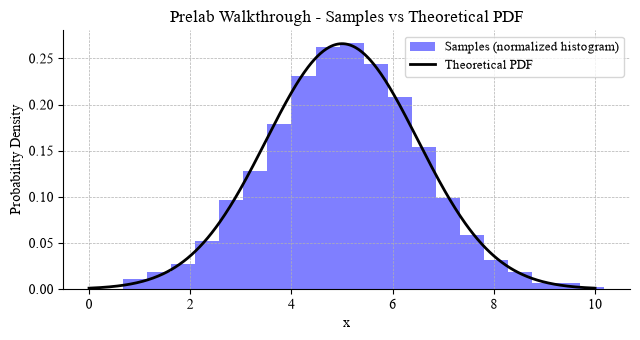

In [55]:
def normal_pdf(x, mu, sigma):
    """Evaluate the normal probability density function at x."""
    return (1.0 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

x_pdf = np.linspace(0, 10, 500)    # 500 evenly spaced x values

fig4, ax4 = plt.subplots(figsize=(6.5, 3.5))
fig4.patch.set_facecolor('white')

# density=True normalizes the histogram so it's comparable to the PDF curve
ax4.hist(data, bins=20, density=True, color='blue', alpha=0.5,
         label='Samples (normalized histogram)')
ax4.plot(x_pdf, normal_pdf(x_pdf, mu, sigma), color='black', linewidth=2,
         label='Theoretical PDF')

ax4.set_xlabel('x')
ax4.set_ylabel('Probability Density')
ax4.set_title('Prelab Walkthrough - Samples vs Theoretical PDF')
ax4.legend(fontsize=9)
ax4.grid(True, linestyle='--', linewidth=0.5)
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

> 🟦 **CHECKPOINT 5 (report on Canvas):**